[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Device set to use cpu



image 1/1 /content/unique_frames/frame_65.jpg: 384x640 1 Line-chart, 182.8ms
Speed: 2.2ms preprocess, 182.8ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/unique_frames/frame_138.jpg: 384x640 1 Geographical-Map, 179.2ms
Speed: 1.8ms preprocess, 179.2ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/unique_frames/frame_25.jpg: 384x640 1 Pyramid-chart, 170.3ms
Speed: 1.9ms preprocess, 170.3ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/unique_frames/frame_140.jpg: 384x640 1 Geographical-Map, 165.6ms
Speed: 2.1ms preprocess, 165.6ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/unique_frames/frame_88.jpg: 384x640 (no detections), 185.9ms
Speed: 2.4ms preprocess, 185.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/unique_frames/frame_104.jpg: 384x640 1 Geographical-Map, 171.6ms
Speed: 2.4ms pr

Filtering people: 100%|██████████| 27/27 [00:04<00:00,  6.03it/s]
/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
Your max_length is set to 128, but your input_length is only 109. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=54)
Your max_length is set to 128, but your input_length is only 112. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=56)
Your max_length is set to 128, but your input_length is only 112. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', ma

📚 Final Notes


## PN Junction: A Comprehensive Overview

### Introduction

Many semiconductor devices, including LEDs, BJTs, photodetectors, and solar cells, rely on the PN junction. This document summarizes the key operational principles, characteristics, and applications of PN junctions, including diffusion currents, biasing, and breakdown mechanisms.

### PN Junction Basics

A PN junction in equilibrium exhibits a built-in potential and a depletion region with a specific width (W). Applying forward or reverse bias modifies the depletion width and built-in potential.  Forward bias reduces the depletion width and allows current to flow, while reverse bias increases it, resulting in a small leakage current.  This rectifying behavior forms the basis of diode operation, allowing current flow in one direction and blocking it in the other.

### PN Junction as an LED

A PN junction can function as a Light Emitting Diode (LED) under forward bias. In a direct bandgap semiconductor, electrons and holes recombine in the depletion region, emitting light.  However, simple PN junction LEDs are inefficient due to several factors:

* **Non-radiative recombination:** Trap states within the depletion region facilitate non-radiative recombination, which does not produce light.
* **Photon absorption:** Emitted photons can be reabsorbed by the surrounding semiconductor material, limiting light output.
* **Low recombination rate:** The recombination rate in a simple PN junction is low, requiring a large number of electron-hole pairs for significant light emission.

Efficient LED designs address these limitations through optimized structures and materials. LED operation occurs in the first quadrant of the PN junction I-V characteristics, requiring a voltage slightly above the turn-on voltage.

### PN Junction as a Photodetector

The same PN junction structure can also serve as a photodetector.  When light shines on the depletion region, photons excite electrons from the valence band to the conduction band, creating electron-hole pairs.  The built-in electric field separates these carriers, generating a photocurrent. While photodetectors can operate without bias, a small reverse bias (-2V to -5V) is typically applied.  The resulting current under illumination consists of the dark current (reverse saturation current) and the photocurrent.  The bandgap of the semiconductor must be less than or equal to the energy of the incident photons for detection. Photodetector operation falls within the third quadrant of the I-V characteristics.


### PN Junction as a Solar Cell

Solar cells, essentially specialized PN junctions, generate electricity from sunlight.  While variations like P+N or N+P junctions exist for improved efficiency, the core principle remains the same.  Solar cells operate without an external power source, generating a short-circuit current under illumination. When connected to a load, the operating point lies in the fourth quadrant of the I-V characteristics. The cell's efficiency is determined by the ratio of the power delivered to the load to the total power in the incident sunlight. The spectral response of a solar cell is crucial, aiming to absorb the maximum energy from the solar spectrum, which peaks around 500-550nm.

### PN Junction Breakdown

PN junction breakdown occurs under large reverse bias, characterized by a sudden increase in reverse leakage current. This can destructively damage the device if the current is not limited. Breakdown primarily occurs in reverse bias because the large electric field across the depletion region accelerates carriers to high energies, leading to impact ionization. Two main breakdown mechanisms exist:

* **Zener breakdown:** Tunneling of carriers across the depletion region under high electric fields.
* **Avalanche breakdown:** Impact ionization, where high-energy carriers generate additional electron-hole pairs through collisions, leading to a rapid increase in current.

Understanding breakdown mechanisms is critical for designing and operating PN junction devices reliably.


### Conclusion

The PN junction is a fundamental building block in semiconductor technology, enabling diverse functionalities like light emission, light detection, and energy harvesting. Understanding its operating principles, characteristics, and limitations is crucial for effectively utilizing its potential in various electronic and optoelectronic applications.  Further exploration of topics like capacitance profiling and detailed breakdown analysis will provide a deeper understanding of these devices.


🖼️ Diagrams:


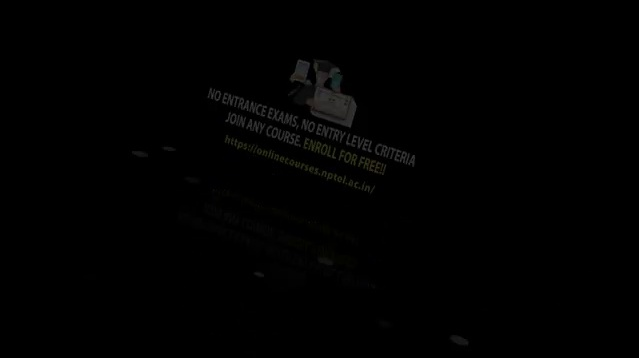

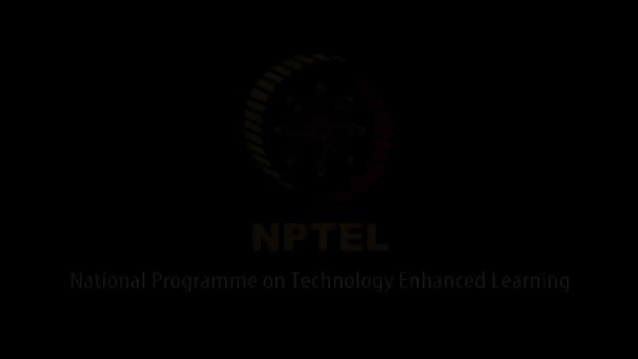

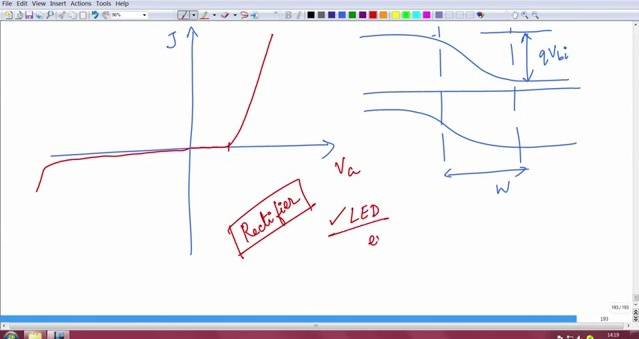

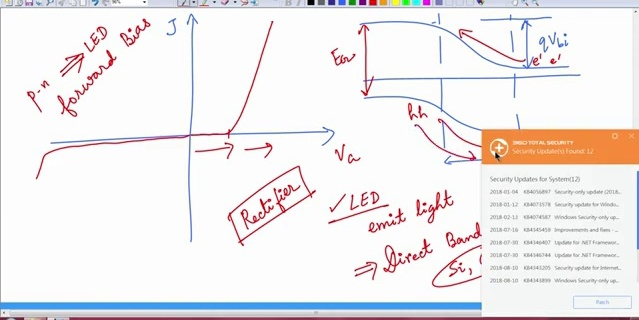

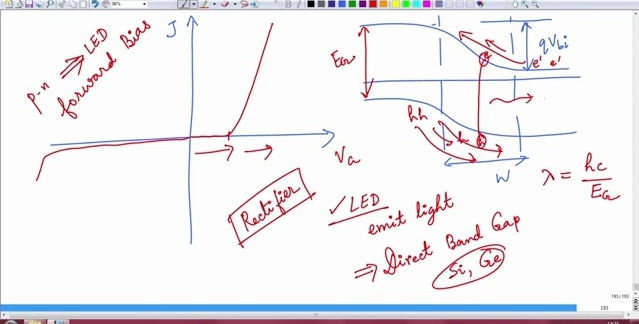

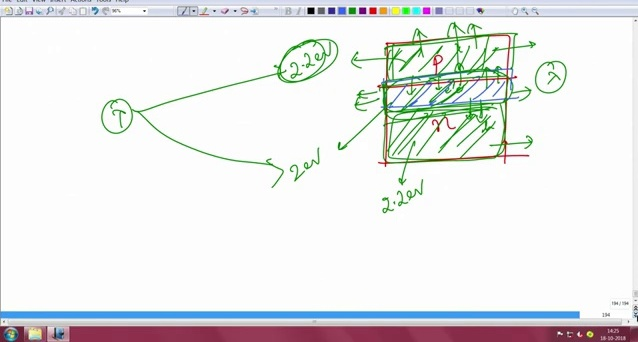

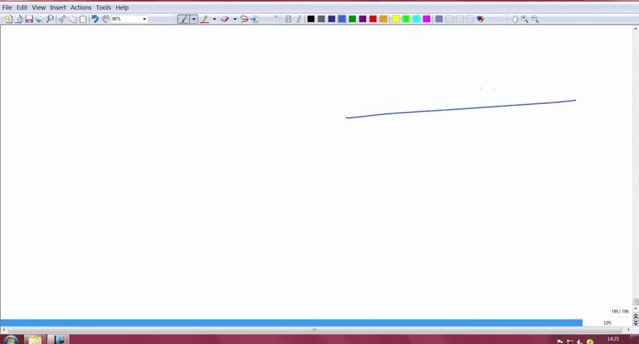

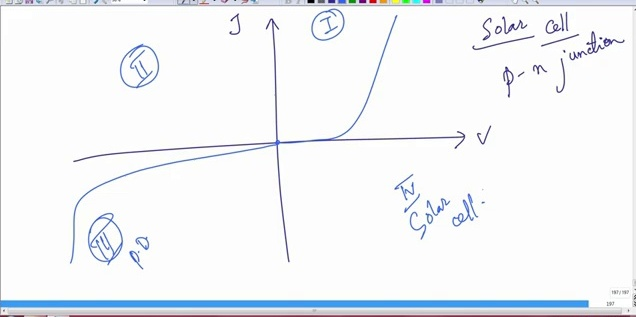

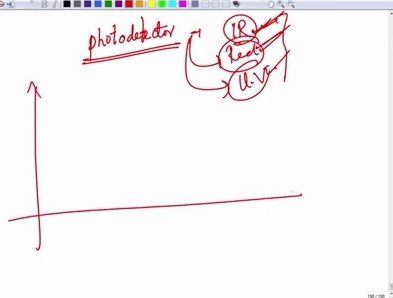

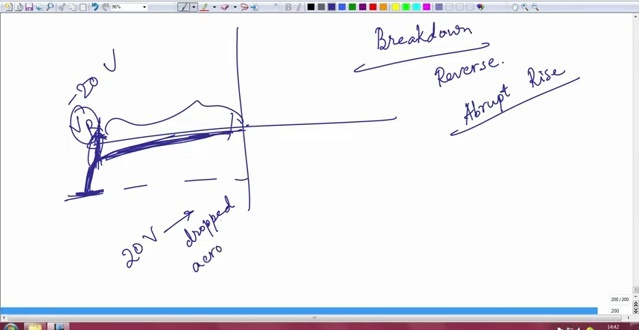

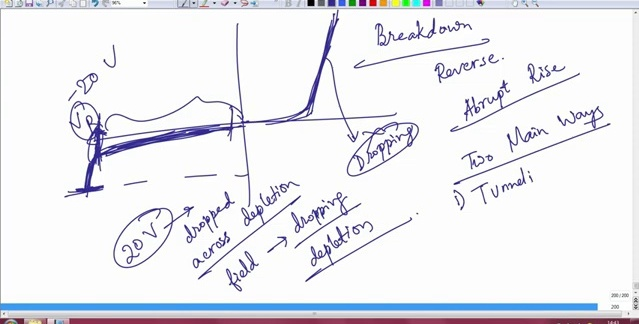

In [8]:
# Install required libraries
!pip install openai-whisper ffmpeg-python transformers torch --quiet
!pip install hf_xet ultralytics scikit-image opencv-python tqdm noisereduce nltk soundfile librosa --quiet

# Imports
import os
import cv2
import shutil
import ffmpeg
import whisper
import librosa
import numpy as np
import soundfile as sf
import noisereduce as nr
from tqdm import tqdm
from nltk.tokenize import sent_tokenize
from skimage.metrics import structural_similarity as ssim
from transformers import pipeline
from ultralytics import YOLO
from gemini_summarizer import summarize
from IPython.display import display, Image, Markdown
import nltk
nltk.download('punkt')

# Paths (set your video and model path here)
video_path = "/content/Application of p-n junctions.mp4"        # uploaded video
diagram_model_path = "/content/best.pt"       # your custom YOLOv8 model
diagram_model = YOLO(diagram_model_path)
person_model = YOLO('yolov8n.pt')              # COCO pretrained
whisper_model = whisper.load_model("base")
summarizer = pipeline('summarization', model='facebook/bart-large-cnn')

# --- Utility Functions ---
def extract_unique_frames(video_path, output_folder, similarity_threshold=0.90, target_fps=1):
    cap = cv2.VideoCapture(video_path)
    os.makedirs(output_folder, exist_ok=True)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = int(fps // target_fps)
    prev_frame = None
    frame_count = 0
    saved_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % frame_interval != 0:
            frame_count += 1
            continue
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if prev_frame is None:
            save_path = os.path.join(output_folder, f"frame_{saved_count}.jpg")
            cv2.imwrite(save_path, frame)
            prev_frame = gray
            saved_count += 1
        else:
            if gray.shape != prev_frame.shape:
                gray = cv2.resize(gray, (prev_frame.shape[1], prev_frame.shape[0]))
            score, _ = ssim(prev_frame, gray, full=True)
            if score < similarity_threshold:
                save_path = os.path.join(output_folder, f"frame_{saved_count}.jpg")
                cv2.imwrite(save_path, frame)
                prev_frame = gray
                saved_count += 1
        frame_count += 1
    cap.release()

def detect_and_crop_diagrams(input_folder, output_folder, model, conf_threshold=0.5):
    os.makedirs(output_folder, exist_ok=True)
    for image_name in os.listdir(input_folder):
        image_path = os.path.join(input_folder, image_name)
        image = cv2.imread(image_path)
        results = model(image_path)
        for i, box in enumerate(results[0].boxes):
            if float(box.conf[0]) > conf_threshold:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cropped = image[y1:y2, x1:x2]
                cv2.imwrite(os.path.join(output_folder, f"{image_name[:-4]}_crop_{i}.jpg"), cropped)

def filter_crops_by_size(frames_dir, crops_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    sample_frame = cv2.imread(os.path.join(frames_dir, os.listdir(frames_dir)[0]))
    frame_h, frame_w = sample_frame.shape[:2]
    for fname in os.listdir(crops_dir):
        path = os.path.join(crops_dir, fname)
        img = cv2.imread(path)
        if img is not None:
            h, w = img.shape[:2]
            if h < frame_h and w < frame_w:
                shutil.copy(path, os.path.join(output_dir, fname))

def contains_person(results, conf_thresh=0.3, min_area=10000):
    for result in results:
        for box in result.boxes:
            if int(box.cls[0]) == 0 and float(box.conf[0]) > conf_thresh:
                x1, y1, x2, y2 = box.xyxy[0]
                if (x2 - x1) * (y2 - y1) > min_area:
                    return True
    return False

def filter_out_people(input_folder, output_folder, model):
    os.makedirs(output_folder, exist_ok=True)
    for img_name in tqdm(os.listdir(input_folder), desc="Filtering people"):
        img_path = os.path.join(input_folder, img_name)
        img = cv2.imread(img_path)
        results = model.predict(source=img, classes=[0], conf=0.3, verbose=False)
        if not contains_person(results):
            shutil.copy(img_path, os.path.join(output_folder, img_name))

def extract_audio(video_path, output_audio):
    ffmpeg.input(video_path).output(output_audio, acodec="mp3").run(overwrite_output=True)

def preprocess_audio(input_audio, output_audio):
    temp_audio = "temp.wav"
    ffmpeg.input(input_audio).output(temp_audio, ar=16000, ac=1, acodec="pcm_s16le").run(overwrite_output=True)
    audio, sr = librosa.load(temp_audio, sr=16000)
    reduced_audio = nr.reduce_noise(y=audio, sr=sr)
    sf.write(output_audio, reduced_audio, sr)
    os.remove(temp_audio)

def transcribe_audio(audio_file):
    result = whisper_model.transcribe(audio_file)
    return result["text"]

def split_text(text, max_tokens=900):
    sentences = sent_tokenize(text)
    chunks, current_chunk = [], ""
    for sentence in sentences:
        if len(current_chunk + sentence) < max_tokens:
            current_chunk += " " + sentence
        else:
            chunks.append(current_chunk.strip())
            current_chunk = sentence
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

def summarize_text(text):
    chunks = split_text(text)
    summaries = [summarizer(chunk, max_length=128, num_beams=8)[0]['summary_text'] for chunk in chunks]
    final_summary = " ".join(summaries)
    return summarize(final_summary)

# === MAIN PIPELINE ===
def full_pipeline(video_path):
    unique_frames_dir = "/content/unique_frames"
    diagram_crops_dir = "/content/diagram_crops"
    filtered_crops_dir = "/content/filtered_crops"
    final_output_dir = "/content/final_images"
    audio_mp3 = "audio.mp3"
    audio_clean = "processed_audio.wav"

    extract_unique_frames(video_path, unique_frames_dir)
    detect_and_crop_diagrams(unique_frames_dir, diagram_crops_dir, diagram_model)
    filter_crops_by_size(unique_frames_dir, diagram_crops_dir, filtered_crops_dir)
    filter_out_people(filtered_crops_dir, final_output_dir, person_model)

    extract_audio(video_path, audio_mp3)
    preprocess_audio(audio_mp3, audio_clean)
    transcript = transcribe_audio(audio_clean)
    summary = summarize_text(transcript)

    # Display results
    print("📚 Final Notes")
    display(Markdown(summary))
    print("🖼️ Diagrams:")
    for image_file in sorted(os.listdir(final_output_dir)):
        display(Image(os.path.join(final_output_dir, image_file)))

# Run it
full_pipeline(video_path)


# 📘 Lecture Summary with Diagrams

---
### 🔹 Point 1:
- Many of the devices like LEDs, BJTs, photo detectors and solar cells they are all based on PN junction.

![Diagram 1](//content/final_diagrams/frame_00186_crop_0.jpg)

---
### 🔹 Point 2:
- So, you know I said that we will pause for sometime in this lecture and we will try to look back.

![Diagram 2](//content/final_diagrams/frame_00208_crop_0.jpg)

---
### 🔹 Point 3:
- We understand that there are different diffusion currents when you apply bias.

---
### 🔹 Point 4:
- PN junction band diagram again.

---
### 🔹 Point 5:
- We will look at the simple PN junction we calling from the last lecture and see how it can enable different kinds of devices just the basic pins.

---
### 🔹 Point 6:
- Of course, there will be more discussions on all these devices in later part of the course.

---
### 🔹 Point 7:
- The PN junction in equilibrium has its own diffusion link, inclusion width we can say W and as I told you that if you apply forward on reverse bias the diffusion width can either increase or decrease the built in potential that you have here.

---
### 🔹 Point 8:
- The reverse bias side it is very small current eventually it will be strong right.

---
### 🔹 Point 9:
- To emit light your semiconductor needs to be a direct bandwidth semiconductor which again we have discussed many times.

---
### 🔹 Point 10:
- So, that is why it is a rectifier because it allows current to flow in one direction and does not allow current to Flow in the other direction.

---
### 🔹 Point 11:
- Now, I had briefly mentioned that how this can be used as an LED which means how can you emit light from this? An LED for a PN junction can behave as an LED when you forward bias it.

---
### 🔹 Point 12:
- So, when you applied forward bias which means you are injecting electrons from this side to that side.

---
### 🔹 Point 13:
- In such a case if it is a direct band gap semiconductor it could emit light.

---
### 🔹 Point 14:
- Light could come out from here but of course, this is not an efficient LED.

---
### 🔹 Point 15:
- So, that will emit light if they are trap states here which be combined with the trap states help in a recombination of electrons and holes that are non radiative not emit light.

---
### 🔹 Point 16:
- In general it is possible the electrons and holes that are crossing here in a direct mangue semiconductor would be able to recombine radiatively and emit some light.

---
### 🔹 Point 17:
- So, how you do that we shall discuss when we actually come up with LED chapter you know with heteroscience and compound semiconductor.

---
### 🔹 Point 18:
- When electrons and holes recombine in the depletion region here you know they emit light the emitted light cannot come out here.

---
### 🔹 Point 19:
- This area has the same band gap as this area.

---
### 🔹 Point 20:
- Another problem this is not a good LED is that when the light is emitted from here you see the band gap of this side.

---
### 🔹 Point 21:
- The wavelength of light that is emitted will be actually corresponding to the band gap here also right.

---
### 🔹 Point 22:
- So, the photons will get absorbed and will very small fraction could come out.

---
### 🔹 Point 23:
- Of course, it can come out to the side but that is a very tiny you know fraction that might come out here.

---
### 🔹 Point 24:
- B n junction can behave like an LED and it is operated at the forward bias which means that you have a you your turn and voltage is very important.

---
### 🔹 Point 25:
- So, your your your P n junction is operated in this region this region ok.

---
### 🔹 Point 26:
- The it is called the first quadrant.

---
### 🔹 Point 27:
- This is the second quadrant this is the third quadrant and this iscalled the fourth quadrant of a B n junction IV.

---
### 🔹 Point 28:
- LED is operated in the first first quadrant here.

---
### 🔹 Point 29:
- In this regime in this regime you will not get any light because the current is very low.

---
### 🔹 Point 30:
- So, for example, that if the turn on voltage is 2 whole you on the operate may be at 2.2 or 2.3 volts slightly above the operation.

---
### 🔹 Point 31:
- The most important things happen in the deposition region only.

---
### 🔹 Point 32:
- Not the same structure can be used also as a photoretector.

---
### 🔹 Point 33:
- A Photoretector basically detects light.

---
### 🔹 Point 34:
- The same concept of a P n junction this is the same P n concept.

---
### 🔹 Point 35:
- See the PN junction everything you know.

---
### 🔹 Point 36:
- In a semiconductor based photoretector what you happen is that you know if I look at the same structure again here is the same thing actually.

---
### 🔹 Point 37:
- So, if you have the formula well and then you have this P n junction here you are shining light suppose in this region the deposition region there is a field here.

---
### 🔹 Point 38:
- If you shine light in this region that photons that are absorbed will be able to excite electron from the valence band to the conduction band leaving behind a hole here right.

---
### 🔹 Point 39:
- So, the one photon will basically release one electron hole pair.

---
### 🔹 Point 40:
- Depending on the intensity of the light if you have a very high intensity of course.

---
### 🔹 Point 41:
- So, what happens is that because there is already an in leaf yield here the electron will be prickly sway up to this site.

---
### 🔹 Point 42:
- This is the reverse direction of the ideal diode current for bias equation.

---
### 🔹 Point 43:
- So, effectively all the current is actually because of hole in electron.

---
### 🔹 Point 44:
- In a PN junction you do not even have to bias the device, if you just keep it like this and you shine light of any wavelength or on any wavelength the wavelength has to correspond to the bandage of the material.

---
### 🔹 Point 45:
- At zero bias you will not get any you know any current otherwise.

---
### 🔹 Point 46:
- When you shine light what will happen is that this curve will shift like this, this extra current that is coming here you know this is called photo current.

---
### 🔹 Point 47:
- This comes because of optical generation of carriers in the depletion region right.

---
### 🔹 Point 48:
- So, even if you do not apply any voltage this is zero voltage right.

---
### 🔹 Point 49:
- In this depletion region the shining light your electrons will come this side holds that are produced, electricity will produce electron whole pairs.

---
### 🔹 Point 50:
- So, of course, you operate in the third quadrant here.

---
### 🔹 Point 51:
- This is at zero bias, this point is zero bias and still there you will get some current this current value is called the photo current.

---
### 🔹 Point 52:
- At minus 5 volt typically you will have very less current because that is the diode reverse saturation current plus the dimension current.

---
### 🔹 Point 53:
- When you shine light you have a lot of optical generation of carriers that are swept away the field.

---
### 🔹 Point 54:
- So, that is why this is called dark current this is the photo current.

---
### 🔹 Point 55:
- The band gap to semiconductor has to be the same as the energy of the photon.

---
### 🔹 Point 56:
- So, for example, you know even a silicon can be a detector for example.

---
### 🔹 Point 57:
- If I am using a silicon photo detector and silicon's band gap is 1.1 EV.

---
### 🔹 Point 58:
- It depends on the semiconductor that you are trying to see for example, if you want to detect an ultraviolet light of say 300 nanometer.

---
### 🔹 Point 59:
- So, together absorb you need to shine a light whose band whose photon wavelength is such that the energy of the photon is equal to a more than the band gap.

---
### 🔹 Point 60:
- A solar cell is sort of a PN junction only although there could be more design variations like it could be P plus N junction or N plus P junction.

---
### 🔹 Point 61:
- Those are there to increase the efficiency and other things but typically it is a solar cell.

---
### 🔹 Point 62:
- Now, you know all over the world solar energy is becoming very cheap.

---
### 🔹 Point 63:
- This is your IV characteristics right and this is the first quadrant where LED wide work again for LED it has to be direct band gap material.

---
### 🔹 Point 64:
- So, silicon cannot be an LED nothing happens in second quadrant.

---
### 🔹 Point 65:
- There is a third quadrant you use it is a photo detector PD of course, you can use it as a zero voltage also.

---
### 🔹 Point 66:
- In a solar cell essentially it is 0 voltage so, it is short both P and N side are short that is called short circuit current.

---
### 🔹 Point 67:
- You are not applying any voltage but the moment you are shining light.

---
### 🔹 Point 68:
- If you do not shine light and you connect a PN junction like this if you wire you are not going to get any current.

---
### 🔹 Point 69:
- Once you shine light electrons and holes will travel and they will be net current that is flowing.

---
### 🔹 Point 70:
- That current is called a short circuit current here this is the current you are getting here.

---
### 🔹 Point 71:
- And then if you be electron in drift side also drift side and then you be current even at 0 voltage that is what happened here.

---
### 🔹 Point 72:
- When you shine light it generates electricity without any voltage without any requirement of any voltage anything and it gives you this current.

---
### 🔹 Point 73:
- Now, you might ask that it is almost the same thing as a photo detector that is true but you do not go into reverse bias you just keep it.

---
### 🔹 Point 74:
- A solar cell is also actually basically a PN junction only.

---
### 🔹 Point 75:
- It will basically come in this this side of the x axis or y axis.

---
### 🔹 Point 76:
- So, basically you are going to get this much current in the real operation.

---
### 🔹 Point 77:
- The field factor is very important because that corresponds to the efficiency of the solar cell.

---
### 🔹 Point 78:
- In a solar cell in a photo detector you can detect you can choose to detect any light.

---
### 🔹 Point 79:
- So, the band gap of the photo detector can be made such that it will only correspond to IR.

---
### 🔹 Point 80:
- But essentially solar cell could be a PN junction only ok and important thing is here.

---
### 🔹 Point 81:
- Sunlight has a particular wavelength distribution and that is corresponding to the black body radiation on the sun.

---
### 🔹 Point 82:
- But in a solar cell it cannot change in solar cell the input spectra is fixed.

---
### 🔹 Point 83:
- So, no matter what material you take you cannot change the inputSpectra.

---
### 🔹 Point 84:
- In UV there is nothing light most of the light is invisible and then here I think it is like 1 or 1.5 micron and so on less light is then IR.

---
### 🔹 Point 85:
- So, you want the solar cell such that this spectra is of absorbed the maximum sense in it that is what you want.

---
### 🔹 Point 86:
- A PN junction definitely has an ideal diode equation.

---
### 🔹 Point 87:
- Ideal diode current which goes as J naught which be power QVA by KT that is what we have studied is the reverse association kind.

---
### 🔹 Point 88:
- It also has a generation recombination current which arises because of trap assisted recombination and other things.

---
### 🔹 Point 89:
- This is your generation recombination current that is I will get that current what will be added together and you know there is a diffusion component that is happening that is why we can get this current we have some solid equation.

---
### 🔹 Point 90:
- So, what is this break down is happening at some break down voltage here right BBR I call it.

---
### 🔹 Point 91:
- capacitance voltage profiling is a powerful tool to measure the properties of a PN junction.

---
### 🔹 Point 92:
- Capacitance voltage is a processor phenomena where a device or diode breaks down.

---
### 🔹 Point 93:
- So, some break down happens here and break down what is this break down and what does it happen.

---
### 🔹 Point 94:
- So, what does actually break down mean ok.

---
### 🔹 Point 95:
- So, what happens at break down why does break down happen all these things are something that you should be aware of.

---
### 🔹 Point 96:
- Break down in generally is not a good thing because break down means that your device is now essentially not going to work beyond the break down point.

---
### 🔹 Point 97:
- When you apply a large reverse bias suddenly there can be a spike of current.

---
### 🔹 Point 98:
- If you do not limit the current a large kind will flow and that large kind would burn the device or destroy the device.

---
### 🔹 Point 99:
- So, a lot of power will be dissipated and the device will be destructively broken down.

---
### 🔹 Point 100:
- Do not let the current increase you know that this is your breakdown that is happening now.

---
### 🔹 Point 101:
- If this is the case you can again come back and operate the device in decision that is not a problem.

---
### 🔹 Point 102:
- But, if you do not let it if you just go it like that in the device will current is very high and the device is burned forever.

---
### 🔹 Point 103:
- When breakdown happens that are suddenly a large number of current increases very small area here range here the current that has suddenly it has increased in the reverse bias not in forward bias.

---
### 🔹 Point 104:
- In reverse bias when you increasing the current from here to here suppose the breakdown voltage is 20 volt minus 20.

---
### 🔹 Point 105:
- So, over 20 volt the current is very low.

---
### 🔹 Point 106:
- On a forward bias side it will not breakdown because there is no voltage blocking the current is increasing very fast.

---
### 🔹 Point 107:
- So, all the field is depleted dropping across the depletion region that is why eventually it will breakdown here.

---
### 🔹 Point 108:
- Only the reverse bias theCurrent is very low you are going to block a voltage and drop a film.

---
### 🔹 Point 109:
- That is why breakdown happens in reverse bands.

---
### 🔹 Point 110:
- There are two main ways in which breakdown can happen.

---
### 🔹 Point 111:
- One is tunneling then I will come to that.

---
### 🔹 Point 112:
- In the second is actually avalence it is called avalence breakdown.

---
### 🔹 Point 113:
- This is a very important breakdown many of the most of the practical devices are limited by avalanche breakdown only.

---
### 🔹 Point 114:
- The PN junction has two important things that are remaining to be covered one is breakdown one is capacitance profiring.

---
### 🔹 Point 115:
- We are starting a breakdown I told you breakdown is you know it occurs when you have a large reverse bias suddenly the reverse leakage current which is very low suddenly increases and if you let it increase then it will burn the device.

---
### 🔹 Point 116:
- In the forward bias current is very high when very high current flows like in a metal you cannot block a voltage you cannot drop a field ok.

---
### 🔹 Point 117:
- So breakdown happens only in reverse bias there are two main mechanisms of breakdown one is tunneling based breakdown it is called zener breakdown associated dino diodes you might have heard about it.

---
### 🔹 Point 118:
- Another breakdown is called avalanche breakdown that is very common breakdown and most of the devices you know are limited by avalanche breakdown ok.

